In [1]:
import os
import random
import cv2
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Data Loading

In [2]:
# Check if dataset exists, if not we clone it
if not os.path.exists('breast_cancer_public_data'):
    print("Cloning dataset...")
    !git clone https://github.com/MachineLearnia/breast_cancer_public_data.git
else:
    print("Dataset already exists.")

BASE_DIR = 'breast_cancer_public_data'
DATA_DIR = os.path.join(BASE_DIR, 'data_2')
CATEGORIES = ["Negative", "Cancer"] 

print(f"Data directory set to: {DATA_DIR}")

Dataset already exists.
Data directory set to: breast_cancer_public_data\data_2


# Data Preprocessing

In [3]:
IMG_SIZE = 224
data = []

def create_training_data():
    """
    Reads images from the disk, resizes them, and appends them to the data list.
    """
    for category in CATEGORIES:
        path = os.path.join(DATA_DIR, category)
        class_num = CATEGORIES.index(category)  # 0 for Negative, 1 for Cancer
        print(f"{class_num} : {category}")

        # Iterate over each image in the folder
        for img in tqdm.tqdm(os.listdir(path), desc=f"Loading {category}"):
            try:
                img_array = cv2.imread(os.path.join(path, img))
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
                data.append([new_array, class_num])
            except Exception as e:
                print(e)
                
create_training_data()
print(f"\nTotal images loaded: {len(data)}")

0 : Negative


Loading Negative: 100%|██████████| 410/410 [00:00<00:00, 477.08it/s]


1 : Cancer


Loading Cancer: 100%|██████████| 410/410 [00:00<00:00, 412.89it/s]


Total images loaded: 820


# Prepare Features and Labels

In [4]:
# Shuffle data to ensure the model doesn't learn the order of classes
random.shuffle(data)
X=[]
y=[]
for features,label in data:
    X.append(features)
    y.append(label)

X=np.array(X).reshape(-1,IMG_SIZE,IMG_SIZE,3)
y=np.array(y)
print(f"X_sahpe:{X.shape} \ny_sahpe:{y.shape}")

X_sahpe:(820, 224, 224, 3) 
y_sahpe:(820,)


# Normalization

In [5]:
# Normalize pixel values to be between 0 and 1
X=X/255.0
print("Min:", X.min())
print("Max:", X.max())

Min: 0.0
Max: 1.0


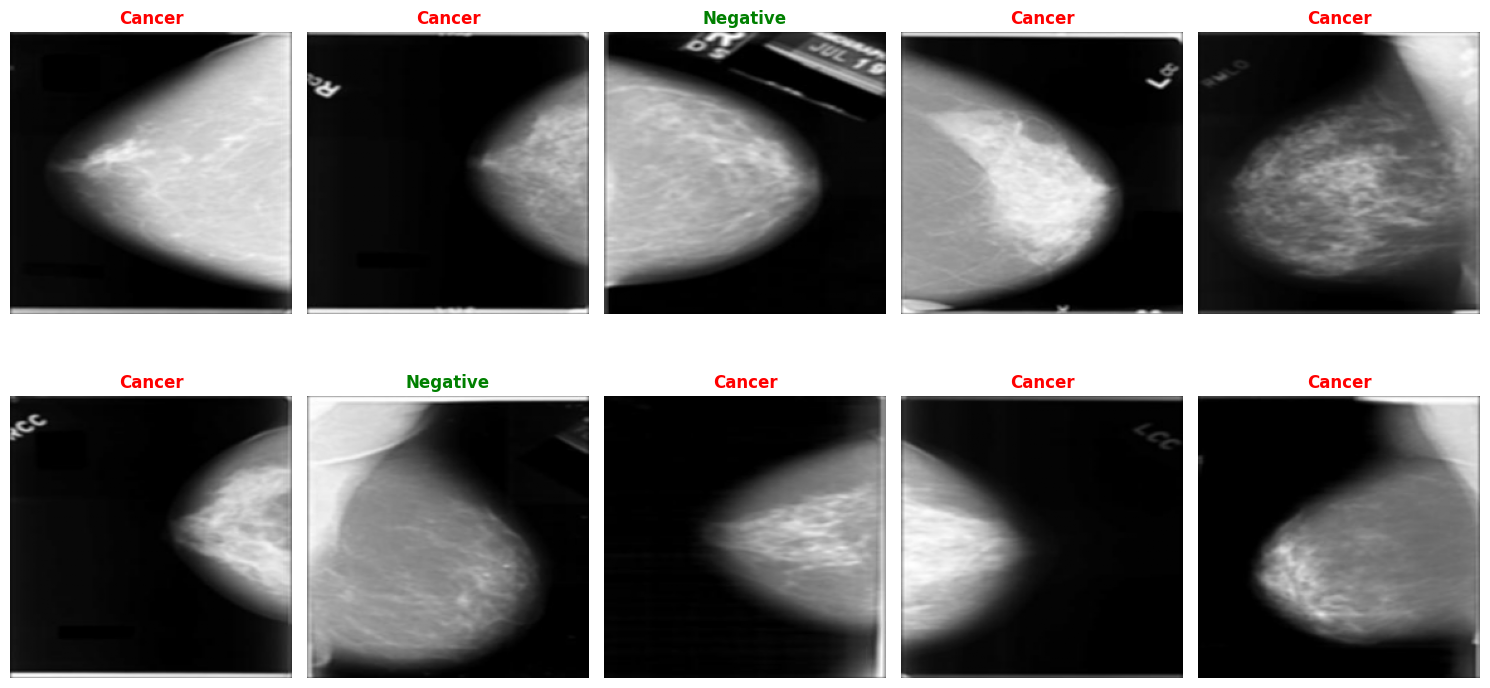

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_random_images(X, y, class_labels, num_images=10):
    """
    Displays random images from the dataset along with their corresponding class labels.
    """
    indices = np.random.choice(len(X), num_images, replace=False)
    
    plt.figure(figsize=(15, 8))
    
    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i + 1) 
        plt.imshow(X[idx])
 
        label_index = int(y[idx])
        class_name = class_labels[label_index] # Convert index to name (Negative/Cancer)
        color = 'green' if label_index == 0 else 'red'
        plt.title(f"{class_name}", color=color, fontsize=12, fontweight='bold')
        plt.axis('off') 

    plt.tight_layout()
    plt.show()

class_names = ['Negative', 'Cancer']

visualize_random_images(X, y, class_names, num_images=10)

# Train/Test Split

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)

(656, 224, 224, 3)
(164, 224, 224, 3)
(656,)


# Data Augmentation

In [8]:
data_generation = ImageDataGenerator(
    rotation_range=20,     
    width_shift_range=0.1,  
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,      
    fill_mode='nearest'
)

# Training of CNN Model 

In [9]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [10]:
model.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [11]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [12]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [13]:
history = model.fit(
    data_generation.flow(X_train, y_train, batch_size=32), 
    epochs=50,
    validation_data=(X_test, y_test),
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 194s 9s/step - accuracy: 0.5168 - loss: 0.7236 - val_accuracy: 0.5427 - val_loss: 0.6808 - learning_rate: 1.0000e-04
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 280s 13s/step - accuracy: 0.4939 - loss: 0.7206 - val_accuracy: 0.6341 - val_loss: 0.6718 - learning_rate: 1.0000e-04
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 321s 13s/step - accuracy: 0.5427 - loss: 0.7005 - val_accuracy: 0.7927 - val_loss: 0.6613 - learning_rate: 1.0000e-04
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 280s 13s/step - accuracy: 0.5442 - loss: 0.6987 - val_accuracy: 0.7134 - val_loss: 0.6576 - learning_rate: 1.0000e-04
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 278s 13s/step - accuracy: 0.5396 - loss: 0.6874 - val_accuracy: 0.7744 - val_loss: 0.6455 - learning_rate: 1.0000e-04
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 266s 13s/step - accuracy: 0.5762 - loss: 0.6803 - val_accuracy: 0.7500 - val_loss: 0.6420 - learning_rate: 1.0000e-04
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 230s 11s/step - accuracy: 0

# Performance Visualization

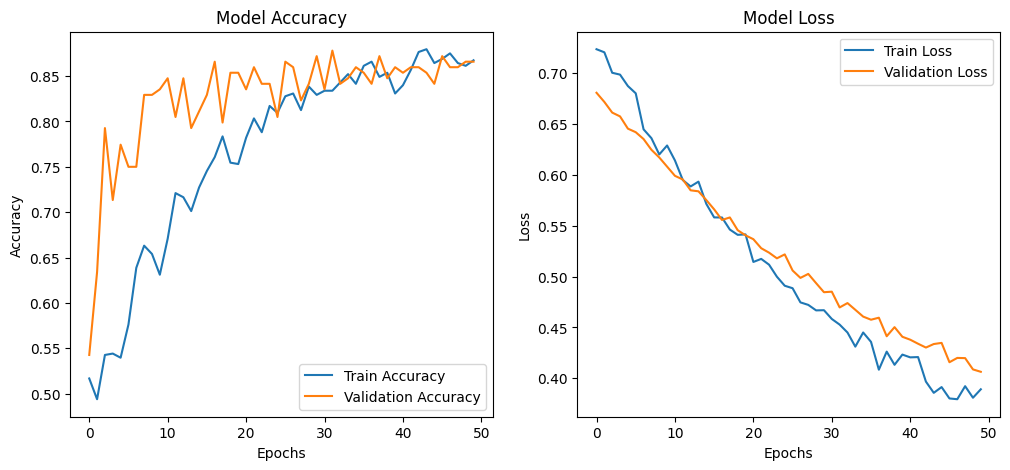

In [14]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

# Plot Accuracy~
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Evaluation & Confusion Matrix

6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8659 - loss: 0.4064
Test Accuracy: 86.59%
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step

Classification Report:

              precision    recall  f1-score   support

    Negative       0.80      0.95      0.87        78
      Cancer       0.94      0.79      0.86        86

    accuracy                           0.87       164
   macro avg       0.87      0.87      0.87       164
weighted avg       0.88      0.87      0.87       164



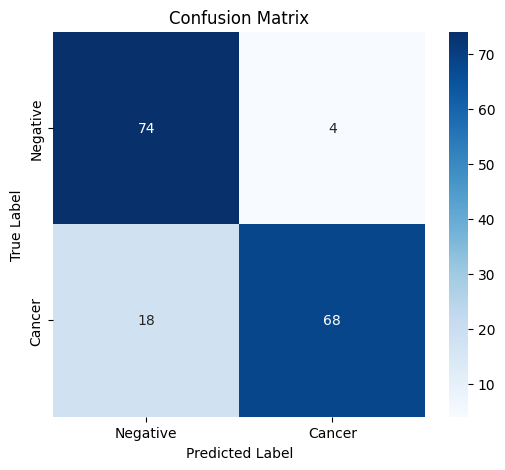

In [15]:
# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Generate predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CATEGORIES))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()